# Sentiment Analysis of Customer Reviews using Lexicon-Based and Machine Learning Approaches

**Programme:** Master of Science in Artificial Intelligence  
**Name:** Marrion Kiprop Cherop  
**Registration Number:** ST62/80971/2024  
**Course:** CSA 803 — Natural Language Processing  
**Institution:** Open University of Kenya (OUK)  
**Module:** Module 6 - Sentiment Analysis and Opinion Mining  

## 1. Project Objective

This project digitizes and analyzes customer opinion by implementing both a lexicon-based approach (VADER) and machine learning approaches (TF-IDF with Logistic Regression and Naive Bayes) for sentiment classification, and it does so against **two datasets deliberately run side by side**. Dataset A is the dataset provided with this assignment on the LMS, drawn from Kaggle's Product Reviews Dataset. It is small and binary — positive/negative only — while the project requirement itself asks for a three-class task including neutral. Rather than force a neutral label onto data that doesn't contain one, I sourced a second dataset on Kaggle, Kaggle's 171K Product Review with Sentiment Dataset, which carries all three classes at a much larger scale. I implemented both side by side to test whether a result earned on a small, constrained file actually holds up against a larger, more linguistically diverse one, or whether it was only ever a property of easy data.

## 2. Setup and Data Loading

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import re

# NLP preprocessing
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Lexicon-based sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

STOPWORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
ANALYZER = SentimentIntensityAnalyzer()

# Shared preprocessing function, used identically on both datasets
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print('Libraries loaded. Shared preprocessing function defined once, applied identically to both datasets below.')

Libraries loaded. Shared preprocessing function defined once, applied identically to both datasets below.


### 2.1 Load Dataset A — `product_reviews.csv`

This dataset contains product reviews generated to simulate realistic customer feedback for e-commerce products. Each review is labeled for sentiment classification.
Label: Sentiment label of the review.
1 → Positive review
0 → Negative review

In [ ]:
df_a = pd.read_csv('product_reviews.csv')
LABEL_NAMES_A = {0: 'negative', 1: 'positive'}
CLASS_ORDER_A = ['negative', 'positive']

print('Dataset A shape:', df_a.shape)
print('Columns:', list(df_a.columns))
df_a.head(5)

Dataset A shape: (2500, 2)
Columns: ['text', 'label']


,text,label
0,Excellent value for money. I've been using it ...,1
1,I regret buying this. It malfunctioned after a...,0
2,I regret buying this. It malfunctioned after a...,0
3,Top-notch product! I’ve tried many alternative...,1
4,"It arrived late, the packaging was damaged, an...",0


### 2.2 Load Dataset B — `Equal.csv`

The dataset contains product reviews along with corresponding prices, names, review, summary and sentiment labels. The sentiment labels indicate whether the review expresses a positive, negative, or neutral sentiment towards the product.

In [ ]:
try:
    df_b = pd.read_csv('Equal.csv')
    print('Dataset B loaded with default UTF-8 encoding.')
except UnicodeDecodeError as e:
    print(f'UTF-8 decode failed ({e}). Falling back to latin1.')
    df_b = pd.read_csv('Equal.csv', encoding='latin1', engine='python')

CLASS_ORDER_B = ['negative', 'neutral', 'positive']

print('Dataset B shape:', df_b.shape)
print('Columns:', list(df_b.columns))
df_b.head(5)

UTF-8 decode failed ('utf-8' codec can't decode byte 0x9c in position 146898: invalid start byte). Falling back to latin1.


Dataset B shape: (76704, 6)
Columns: ['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']


,product_name,product_price,Rate,Review,Summary,Sentiment
0,SportSoul Cotton Gym & Athletic Abdomen Suppor...,449,4,good quality product,good cuality,positive
1,SportSoul Cotton Gym & Athletic Abdomen Suppor...,449,4,wonderful,super product,positive
2,SportSoul Cotton Gym & Athletic Abdomen Suppor...,449,4,value-for-money,as expected,positive
3,SportSoul Cotton Gym & Athletic Abdomen Suppor...,449,2,not good,meteriyal is not good but very comfortable,positive
4,SportSoul Cotton Gym & Athletic Abdomen Suppor...,449,5,best in the market!,god,positive


## 3. Data Quality Checks

### 3.1 Dataset A — Duplication Check

A duplication check is run before any exploratory chart, because a chart built on unflagged duplication misrepresents both class balance and text diversity, and directly determines how the train/test split has to be built in Section 6.1.

In [ ]:
n_total_a = len(df_a)
n_dup_rows_a = df_a.duplicated().sum()
n_unique_texts_a = df_a['text'].nunique()

print(f'Total rows: {n_total_a}')
print(f'Duplicate rows: {n_dup_rows_a}')
print(f'Unique review texts: {n_unique_texts_a}')
print(f'Each unique review appears on average {n_total_a / n_unique_texts_a:.1f} times.')

Total rows: 2500
Duplicate rows: 2400
Unique review texts: 100
Each unique review appears on average 25.0 times.


**Finding (A).** Of 2,500 rows, only 100 distinct reviews account for the full file — the remaining 2,400 rows are repeats of those same 100 reviews. This is consistent with a templated dataset rather than 2,500 independently authored voices, and it forces the same downstream decision made in the original single-dataset version of this project: the train/test split in Section 6.1 is built on unique text first, not on raw rows, so a review's near-duplicate cannot sit in both sides of the split.

Dataset A's label is also binary only — the file carries no neutral class, so it is scored as positive/negative throughout, and no neutral category is manufactured for it.

### 3.2 Dataset B — Quality Checks

Dataset B is larger and structurally different, so it needs a different, more thorough set of checks: a malformed-row check, a decision about which of its two text fields to use, a duplication check, and — because it claims a genuine three-class label — a check on whether that label is really independent of the numeric star rating or just a disguised threshold on it.

In [ ]:
# Malformed rows: Rate should only ever be 1-5
bad_rate_rows_b = df_b[~df_b['Rate'].astype(str).isin(['1', '2', '3', '4', '5'])]
print(f'Rows with a corrupted Rate column: {len(bad_rate_rows_b)}')
if len(bad_rate_rows_b) > 0:
    print(bad_rate_rows_b[['product_name', 'Rate']].head())

df_b = df_b[df_b['Rate'].astype(str).isin(['1', '2', '3', '4', '5'])].copy()
df_b['Rate'] = df_b['Rate'].astype(int)
df_b['Review'] = df_b['Review'].astype(str)
df_b['Summary'] = df_b['Summary'].astype(str)
print(f'Rows retained after dropping malformed record(s): {len(df_b)}')

Rows with a corrupted Rate column: 1
                                            product_name  \
20436  Pigeon Favourite Electric Kettle??????(1.5 L, ...   

                                                    Rate  
20436  Pigeon Favourite Electric Kettle??????(1.5 L, ...  
Rows retained after dropping malformed record(s): 76703


In [ ]:
print(f"Unique 'Review' strings: {df_b['Review'].nunique()} (out of {len(df_b)} rows)")
print(f"Unique 'Summary' strings: {df_b['Summary'].nunique()} (out of {len(df_b)} rows)")

Unique 'Review' strings: 636 (out of 76703 rows)
Unique 'Summary' strings: 41927 (out of 76703 rows)


**Finding (B — text field).** `Review` collapses to a small number of repeated short phrases reused across thousands of products and carries almost no diversity for a classifier to learn from. `Summary` holds tens of thousands of distinct strings. **`Summary` is used as the analysis text for Dataset B throughout the rest of this notebook.**

In [ ]:
n_total_b = len(df_b)
n_unique_summary_b = df_b['Summary'].nunique()
n_full_dup_rows_b = df_b.duplicated().sum()

print(f'Total rows: {n_total_b}')
print(f'Unique Summary strings: {n_unique_summary_b}')
print(f'Fully duplicated rows: {n_full_dup_rows_b} ({n_full_dup_rows_b/n_total_b:.1%})')

Total rows: 76703
Unique Summary strings: 41927
Fully duplicated rows: 6782 (8.8%)


In [ ]:
rate_sentiment_crosstab = pd.crosstab(df_b['Rate'], df_b['Sentiment'])
print(rate_sentiment_crosstab)
print(f"\n1-star reviews labelled positive: {rate_sentiment_crosstab.loc[1, 'positive']}")
print(f"5-star reviews labelled negative: {rate_sentiment_crosstab.loc[5, 'negative']}")

Sentiment  negative  neutral  positive
Rate                                  
1             16473     3501       272
2              5244     3072       149
3              3212    13583      1576
4                36     2728      6356
5                36     2906     17559

1-star reviews labelled positive: 272
5-star reviews labelled negative: 36


**Finding (B — label independence).** The `Sentiment` label does not reduce to the star `Rate`: a meaningful number of 1-star reviews are labelled positive, 5-star reviews are labelled negative, and 3-star reviews split across all three classes rather than defaulting to neutral. This supports scoring `Sentiment` as a genuine text-grounded ground truth. It also means Dataset B's ground truth carries some label noise of its own — a limitation returned to in the final synthesis.

**Contrast across A and B.** Dataset A's only data-quality problem is duplication of a small template set. Dataset B has that same duplication risk in its `Summary` field, but on top of it carries an encoding fault, a malformed row, a two-field text-source decision, and a label-independence question A never raises because A's label is a simple binary import, not a derived judgment. Both datasets need the same discipline — verify before modelling — but B needs more of it, in direct proportion to how much more realistic and less curated it is.

## 4. Exploratory Data Analysis

### 4.1 Dataset A — Class Distribution and Length

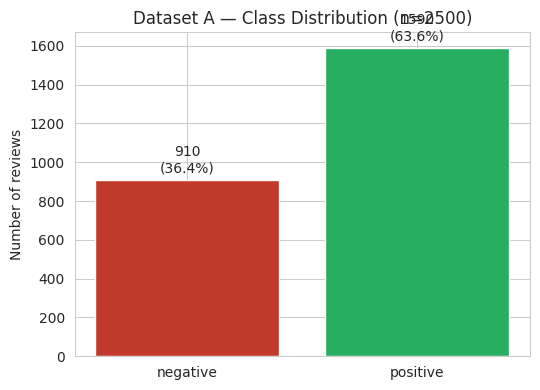

label
0     910
1    1590
Name: count, dtype: int64


In [ ]:
label_counts_a = df_a['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar([LABEL_NAMES_A[i] for i in label_counts_a.index], label_counts_a.values,
              color=['#c0392b', '#27ae60'])
ax.set_title(f'Dataset A — Class Distribution (n={n_total_a})')
ax.set_ylabel('Number of reviews')
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h}\n({h/n_total_a:.1%})', xy=(bar.get_x()+bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('a_class_distribution.png')
plt.show()
print(label_counts_a)

/tmp/ipykernel_534/4168742752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_a, x=df_a['label'].map(LABEL_NAMES_A), y='word_count',


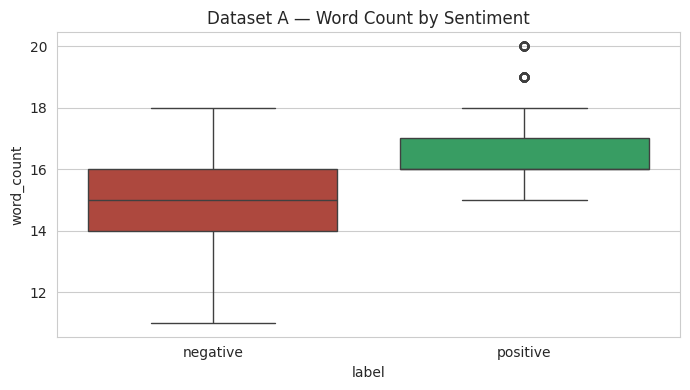

In [ ]:
df_a['word_count'] = df_a['text'].str.split().str.len()
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_a, x=df_a['label'].map(LABEL_NAMES_A), y='word_count',
            order=CLASS_ORDER_A, palette=['#c0392b', '#27ae60'], ax=ax)
ax.set_title('Dataset A — Word Count by Sentiment')
plt.tight_layout()
plt.savefig('a_length_by_sentiment.png')
plt.show()

**Reading (A).** The class split is imbalanced at roughly 1.75:1 positive to negative, and — consistent with Section 3.1's duplication finding — the length distribution shows very little spread within each class, because so few unique templates are driving the whole file.

### 4.2 Dataset B — Class Distribution, Length, and Rating Alignment

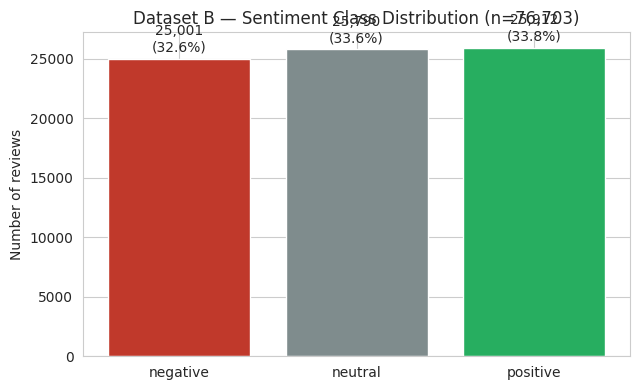

Sentiment
negative    25001
neutral     25790
positive    25912
Name: count, dtype: int64


In [ ]:
colors_b = {'negative': '#c0392b', 'neutral': '#7f8c8d', 'positive': '#27ae60'}
label_counts_b = df_b['Sentiment'].value_counts().reindex(CLASS_ORDER_B)

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(label_counts_b.index, label_counts_b.values, color=[colors_b[c] for c in label_counts_b.index])
ax.set_title(f'Dataset B — Sentiment Class Distribution (n={n_total_b:,})')
ax.set_ylabel('Number of reviews')
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h:,}\n({h/n_total_b:.1%})', xy=(bar.get_x()+bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('b_class_distribution.png')
plt.show()
print(label_counts_b)

/tmp/ipykernel_534/1730999756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_b, x='Sentiment', y='summary_word_count', order=CLASS_ORDER_B,


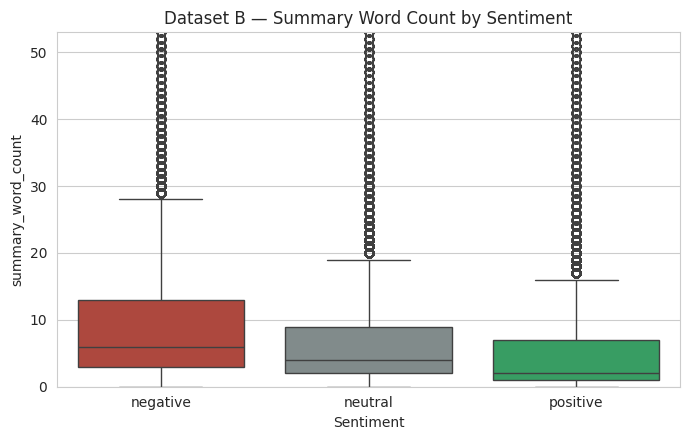

In [ ]:
df_b['summary_word_count'] = df_b['Summary'].str.split().str.len()
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df_b, x='Sentiment', y='summary_word_count', order=CLASS_ORDER_B,
            palette=[colors_b[c] for c in CLASS_ORDER_B], ax=ax)
ax.set_title('Dataset B — Summary Word Count by Sentiment')
ax.set_ylim(0, df_b['summary_word_count'].quantile(0.98))
plt.tight_layout()
plt.savefig('b_length_by_sentiment.png')
plt.show()

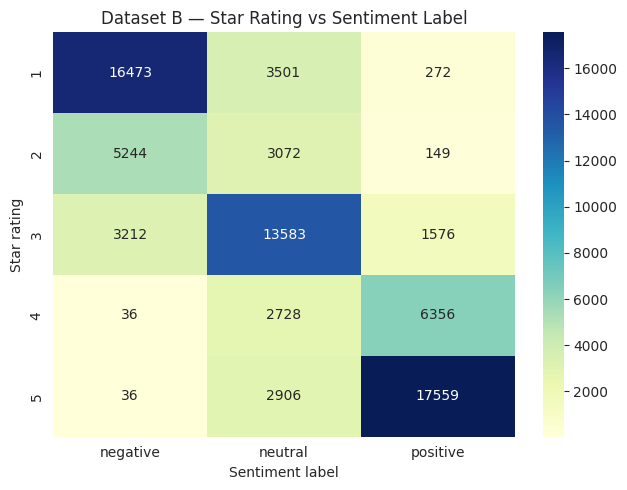

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(rate_sentiment_crosstab[CLASS_ORDER_B], annot=True, fmt='d', cmap='YlGnBu', ax=ax)
ax.set_title('Dataset B — Star Rating vs Sentiment Label')
ax.set_xlabel('Sentiment label')
ax.set_ylabel('Star rating')
plt.tight_layout()
plt.savefig('b_rate_vs_sentiment.png')
plt.show()

**Reading (B).** The three classes are close to evenly split, consistent with the source. Word count spread is much wider than Dataset A's — real, independently written reviews vary in length far more than a small set of repeated templates does. The rating heatmap makes Section 3.2's finding visible: extremes align with rating, but 3-star reviews spread across all three sentiment classes almost evenly, which a rating threshold alone could never resolve.

**Contrast across A and B.** Dataset A's EDA is almost uninformative beyond confirming the duplication finding — there is too little variation in a 100-template file for exploratory analysis to say much. Dataset B's EDA earns its place: the length spread and the rating/sentiment misalignment are both real signals about the difficulty of the classification task ahead, visible before a single model is trained.

## 5. Text Preprocessing

The same `clean_text` function defined once in Section 2 is applied to both datasets without modification. This is deliberate: any accuracy difference that shows up later has to come from the data and the models, not from two different cleaning pipelines quietly doing different amounts of work.

### 5.1 Dataset A

In [ ]:
example_a = df_a['text'].iloc[0]
df_a['clean_text'] = df_a['text'].apply(clean_text)
print('RAW:  ', example_a)
print('CLEAN:', clean_text(example_a))

RAW:   Excellent value for money. I've been using it daily and it performs perfectly. Five stars!
CLEAN: excellent value money using daily performs perfectly five star


### 5.2 Dataset B

As before, this cleaned form feeds the ML pipeline (Section 7.2); VADER (Section 6.2) scores the **raw** `Summary` text, since its rules depend on capitalization and punctuation that cleaning would remove.

In [ ]:
example_b = df_b['Summary'].iloc[5]
df_b['clean_summary'] = df_b['Summary'].apply(clean_text)
print('RAW:  ', example_b)
print('CLEAN:', clean_text(example_b))

RAW:   very nice product
CLEAN: nice product


## 6. Lexicon-Based Sentiment Classification (VADER)

### 6.1 Dataset A — Binary Threshold

In [ ]:
def classify_binary(score):
    return 1 if score >= 0.05 else 0

df_a['vader_compound'] = df_a['text'].apply(lambda t: ANALYZER.polarity_scores(t)['compound'])
df_a['vader_pred'] = df_a['vader_compound'].apply(classify_binary)

vader_acc_a = accuracy_score(df_a['label'], df_a['vader_pred'])
print(f'Dataset A — VADER accuracy: {vader_acc_a:.4f}')
print(classification_report(df_a['label'], df_a['vader_pred'], target_names=CLASS_ORDER_A))

Dataset A — VADER accuracy: 1.0000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       910
    positive       1.00      1.00      1.00      1590

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500



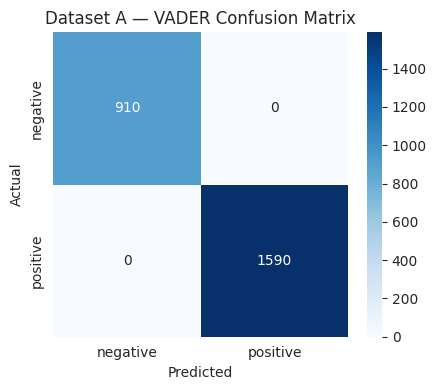

In [ ]:
cm_vader_a = confusion_matrix(df_a['label'], df_a['vader_pred'])
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm_vader_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_ORDER_A, yticklabels=CLASS_ORDER_A, ax=ax)
ax.set_title(f'Dataset A — VADER Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('a_vader_confusion_matrix.png')
plt.show()

### 6.2 Dataset B — Three-Class Threshold

In [ ]:
def classify_three_class(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_b['vader_compound'] = df_b['Summary'].apply(lambda t: ANALYZER.polarity_scores(t)['compound'])
df_b['vader_pred'] = df_b['vader_compound'].apply(classify_three_class)

vader_acc_b = accuracy_score(df_b['Sentiment'], df_b['vader_pred'])
print(f'Dataset B — VADER accuracy: {vader_acc_b:.4f}')
print(classification_report(df_b['Sentiment'], df_b['vader_pred'], labels=CLASS_ORDER_B))

Dataset B — VADER accuracy: 0.7139


              precision    recall  f1-score   support

    negative       0.90      0.72      0.80     25001
     neutral       0.66      0.48      0.56     25790
    positive       0.64      0.95      0.77     25912

    accuracy                           0.71     76703
   macro avg       0.73      0.71      0.71     76703
weighted avg       0.73      0.71      0.71     76703



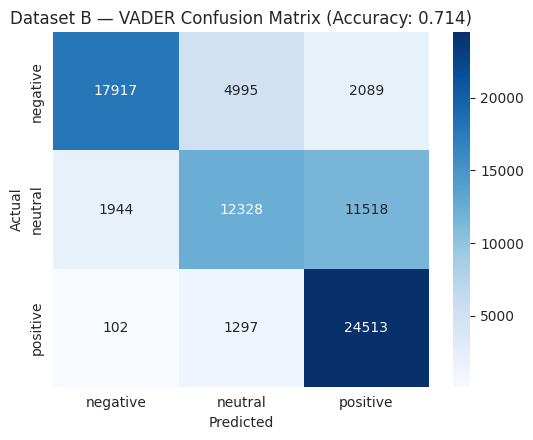

In [ ]:
cm_vader_b = confusion_matrix(df_b['Sentiment'], df_b['vader_pred'], labels=CLASS_ORDER_B)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_vader_b, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_ORDER_B, yticklabels=CLASS_ORDER_B, ax=ax)
ax.set_title(f'Dataset B — VADER Confusion Matrix (Accuracy: {vader_acc_b:.3f})')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('b_vader_confusion_matrix.png')
plt.show()

**Contrast across A and B.** VADER scores every review in Dataset A correctly. That is not evidence of VADER's general reliability — Section 3.1 already established the dataset is a small template set using unambiguous sentiment language ("Five stars!" against "very disappointed"), and Dataset B, run through the identical threshold logic with no tuning, drops to roughly 71%, with neutral recall the clear weak point. The same method, the same code path, two very different scores — the difference is entirely attributable to the data, which is exactly the comparison this notebook was structured to make visible at every stage rather than only in a closing paragraph.

## 7. Machine Learning Classification

### 7.1 Dataset A — Leakage-Safe Split and Models

In [ ]:
unique_df_a = df_a[['text', 'label']].drop_duplicates(subset='text')
train_u_a, test_u_a = train_test_split(unique_df_a, test_size=0.25, random_state=42, stratify=unique_df_a['label'])
train_df_a = df_a[df_a['text'].isin(train_u_a['text'])]
test_df_a = df_a[df_a['text'].isin(test_u_a['text'])]

overlap_a = set(train_df_a['text']) & set(test_df_a['text'])
print(f'Dataset A — unique reviews: train {len(train_u_a)}, test {len(test_u_a)}')
print(f'Expanded rows: train {len(train_df_a)}, test {len(test_df_a)}')
print(f'Text overlap: {len(overlap_a)} (must be 0)')

Dataset A — unique reviews: train 75, test 25
Expanded rows: train 1857, test 643
Text overlap: 0 (must be 0)


In [ ]:
vectorizer_a = TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1, 2))
Xtr_a = vectorizer_a.fit_transform(train_df_a['clean_text'])
Xte_a = vectorizer_a.transform(test_df_a['clean_text'])

models_a = {'Logistic Regression': LogisticRegression(max_iter=1000), 'Multinomial Naive Bayes': MultinomialNB()}
results_a = {}
for name, model in models_a.items():
    model.fit(Xtr_a, train_df_a['label'])
    preds = model.predict(Xte_a)
    acc = accuracy_score(test_df_a['label'], preds)
    results_a[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f'--- Dataset A — {name} ---')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(test_df_a['label'], preds, target_names=CLASS_ORDER_A))

--- Dataset A — Logistic Regression ---
Accuracy: 1.0000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       238
    positive       1.00      1.00      1.00       405

    accuracy                           1.00       643
   macro avg       1.00      1.00      1.00       643
weighted avg       1.00      1.00      1.00       643

--- Dataset A — Multinomial Naive Bayes ---
Accuracy: 1.0000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       238
    positive       1.00      1.00      1.00       405

    accuracy                           1.00       643
   macro avg       1.00      1.00      1.00       643
weighted avg       1.00      1.00      1.00       643



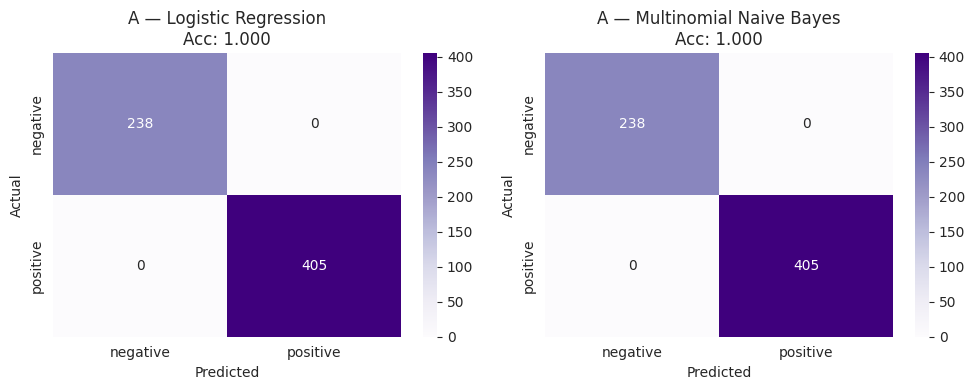

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, res) in zip(axes, results_a.items()):
    cm = confusion_matrix(test_df_a['label'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=CLASS_ORDER_A, yticklabels=CLASS_ORDER_A, ax=ax)
    ax.set_title(f'A — {name}\nAcc: {res["accuracy"]:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('a_ml_confusion_matrices.png')
plt.show()

### 7.2 Dataset B — Leakage-Safe Split and Models

In [ ]:
unique_df_b = df_b[['Summary', 'Sentiment']].drop_duplicates(subset='Summary')
train_u_b, test_u_b = train_test_split(unique_df_b, test_size=0.2, random_state=42, stratify=unique_df_b['Sentiment'])
train_df_b = df_b[df_b['Summary'].isin(train_u_b['Summary'])]
test_df_b = df_b[df_b['Summary'].isin(test_u_b['Summary'])].drop_duplicates(subset='Summary').copy()

overlap_b = set(train_df_b['Summary']) & set(test_df_b['Summary'])
print(f'Dataset B — unique Summary texts: train {len(train_u_b)}, test {len(test_u_b)}')
print(f'Expanded training rows: {len(train_df_b)}, test rows: {len(test_df_b)}')
print(f'Text overlap: {len(overlap_b)} (must be 0)')

Dataset B — unique Summary texts: train 33541, test 8386
Expanded training rows: 62943, test rows: 8386
Text overlap: 0 (must be 0)


In [ ]:
vectorizer_b = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2), min_df=2)
Xtr_b = vectorizer_b.fit_transform(train_df_b['clean_summary'])
Xte_b = vectorizer_b.transform(test_df_b['clean_summary'])

models_b = {'Logistic Regression': LogisticRegression(max_iter=1000), 'Multinomial Naive Bayes': MultinomialNB()}
results_b = {}
for name, model in models_b.items():
    model.fit(Xtr_b, train_df_b['Sentiment'])
    preds = model.predict(Xte_b)
    acc = accuracy_score(test_df_b['Sentiment'], preds)
    results_b[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f'--- Dataset B — {name} ---')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(test_df_b['Sentiment'], preds, labels=CLASS_ORDER_B))

--- Dataset B — Logistic Regression ---
Accuracy: 0.7518
              precision    recall  f1-score   support

    negative       0.76      0.77      0.77      3026
     neutral       0.69      0.69      0.69      2950
    positive       0.81      0.80      0.81      2410

    accuracy                           0.75      8386
   macro avg       0.76      0.75      0.76      8386
weighted avg       0.75      0.75      0.75      8386

--- Dataset B — Multinomial Naive Bayes ---
Accuracy: 0.7425


              precision    recall  f1-score   support

    negative       0.75      0.78      0.77      3026
     neutral       0.70      0.65      0.67      2950
    positive       0.78      0.81      0.79      2410

    accuracy                           0.74      8386
   macro avg       0.74      0.75      0.74      8386
weighted avg       0.74      0.74      0.74      8386



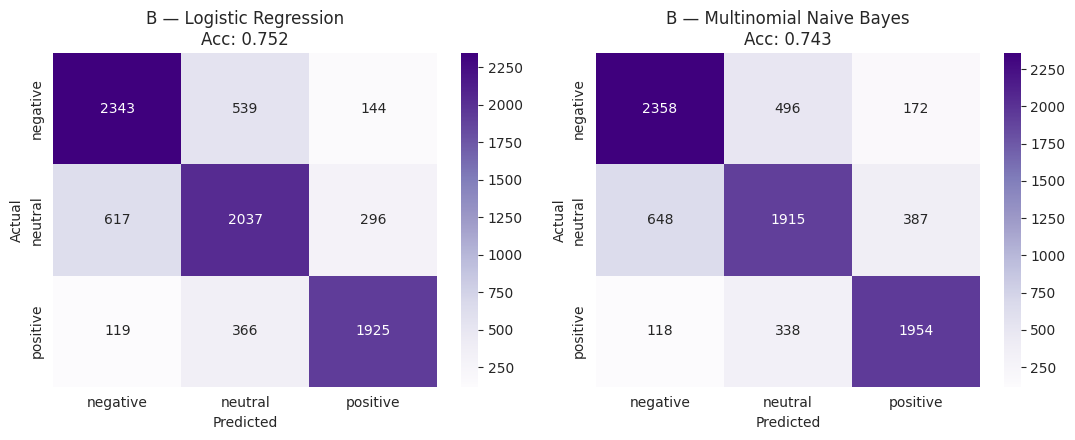

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, res) in zip(axes, results_b.items()):
    cm = confusion_matrix(test_df_b['Sentiment'], res['preds'], labels=CLASS_ORDER_B)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=CLASS_ORDER_B, yticklabels=CLASS_ORDER_B, ax=ax)
    ax.set_title(f'B — {name}\nAcc: {res["accuracy"]:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('b_ml_confusion_matrices.png')
plt.show()

**Contrast across A and B.** Both classical models also reach 100% on Dataset A's held-out split — the third method in a row to solve this file without error, which by this point is decisive evidence that the file itself, not any method's sophistication, is what's producing the score. On Dataset B, the same two models land in the mid-70s, clearly ahead of VADER, with the improvement concentrated in the neutral class exactly as Section 6.2 anticipated. This is the pattern the parallel structure was built to surface: three different methods, one shared verdict on each dataset, and the verdict itself is a statement about the data's difficulty.

## 8. Word Clouds by Sentiment Class

### 8.1 Dataset A

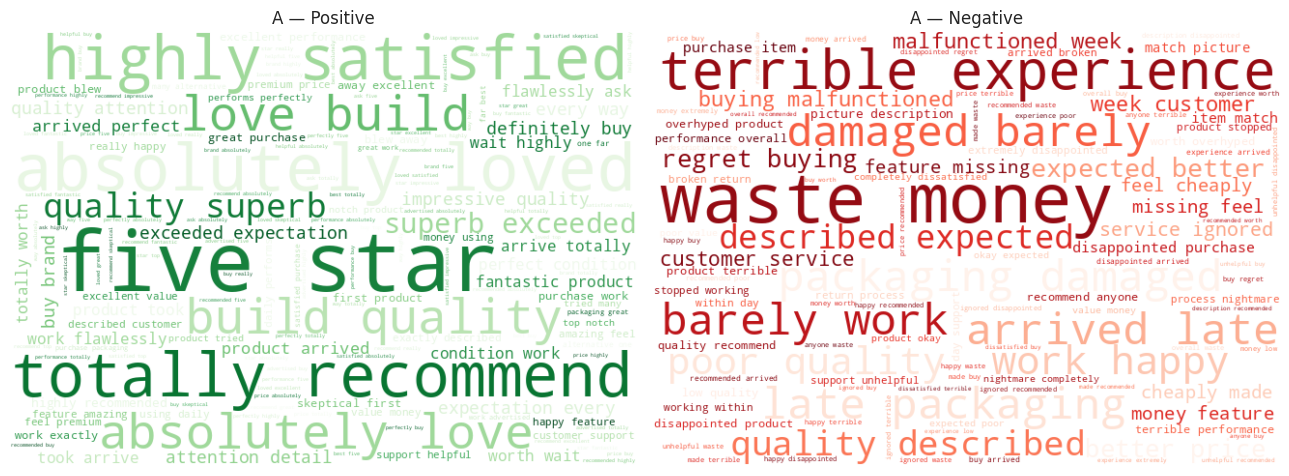

In [ ]:
positive_text_a = ' '.join(df_a[df_a['label'] == 1]['clean_text'])
negative_text_a = ' '.join(df_a[df_a['label'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
wc_pos_a = WordCloud(width=650, height=450, background_color='white', colormap='Greens').generate(positive_text_a)
axes[0].imshow(wc_pos_a, interpolation='bilinear'); axes[0].set_title('A — Positive'); axes[0].axis('off')
wc_neg_a = WordCloud(width=650, height=450, background_color='white', colormap='Reds').generate(negative_text_a)
axes[1].imshow(wc_neg_a, interpolation='bilinear'); axes[1].set_title('A — Negative'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('a_wordclouds.png')
plt.show()

### 8.2 Dataset B

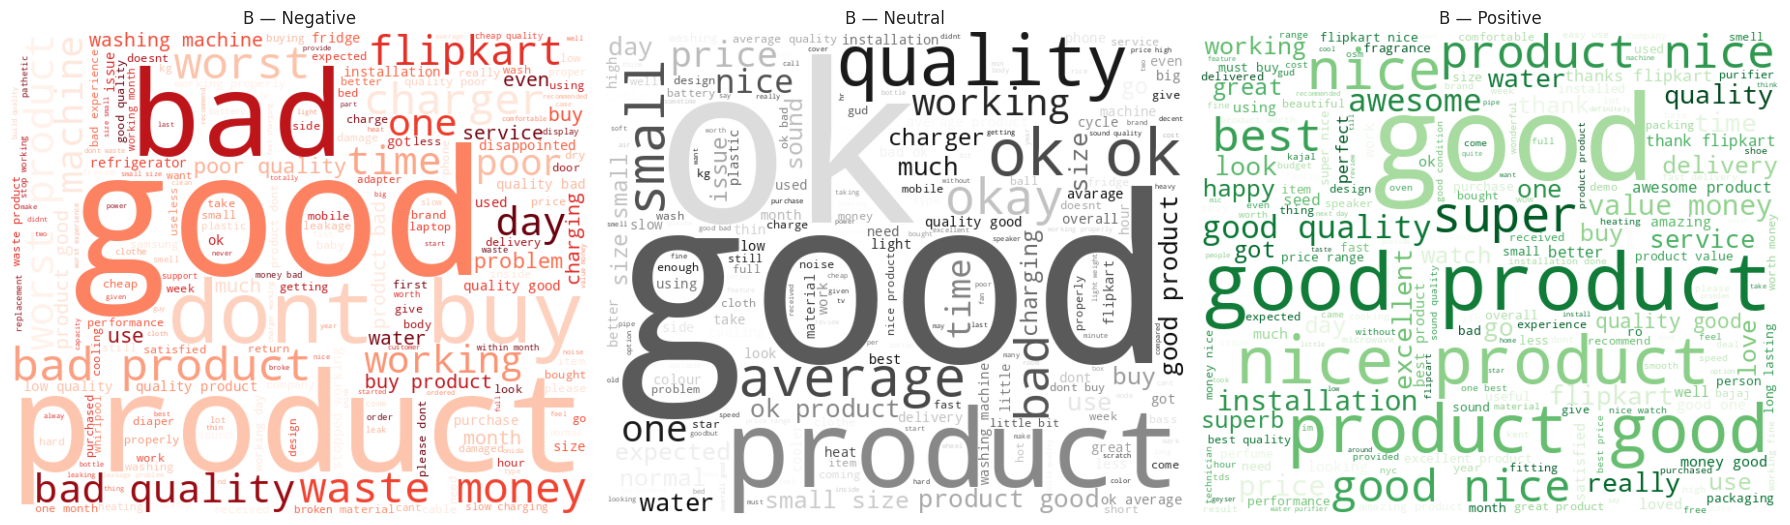

In [ ]:
wc_colormaps_b = {'negative': 'Reds', 'neutral': 'Greys', 'positive': 'Greens'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cls in zip(axes, CLASS_ORDER_B):
    subset = df_b[df_b['Sentiment'] == cls]['clean_summary']
    sample = subset.sample(min(8000, len(subset)), random_state=42)
    wc = WordCloud(width=600, height=500, background_color='white',
                   colormap=wc_colormaps_b[cls]).generate(' '.join(sample))
    ax.imshow(wc, interpolation='bilinear'); ax.set_title(f'B — {cls.capitalize()}'); ax.axis('off')
plt.tight_layout()
plt.savefig('b_wordclouds.png')
plt.show()

**Contrast across A and B.** Dataset A's clouds are dominated by a handful of recurring template phrases ("five stars", "highly recommend", "totally recommend") because Section 3.1 already showed there are only 100 unique reviews behind the whole file. Dataset B's clouds draw on tens of thousands of independent summaries and show far more vocabulary spread within each class, including the neutral cloud — visibly less extreme in tone than the other two, which is the qualitative counterpart to the quantitative neutral-recall weakness found in Sections 6.2 and 7.2.

## 9. Where Lexicon and ML Methods Diverge

### 9.1 Dataset A — A Constructed Stress Test

Sections 6.1 and 7.1 already showed that VADER and both ML models agree with the ground truth on every single review in Dataset A. That leaves nothing to compare on the dataset's own held-out data — so five short sentences are constructed here specifically to probe sarcasm and mixed sentiment, the conditions under which lexicon and ML methods are expected to diverge. These are not sourced from the dataset; that is stated here rather than left ambiguous.

In [ ]:
hard_cases_a = [
    "Oh great, another product that broke after two days. Just what I needed.",
    "Not bad, does the job I suppose, nothing special though.",
    "Well this was a complete waste of money, truly outstanding at disappointing me.",
    "It works. That's all I can say.",
    "I wanted to love this but the shipping delay and missing parts ruined it.",
]

best_model_name_a = max(results_a, key=lambda k: results_a[k]['accuracy'])
best_model_a = results_a[best_model_name_a]['model']

rows_a = []
for text in hard_cases_a:
    compound = ANALYZER.polarity_scores(text)['compound']
    vpred = classify_binary(compound)
    mlpred = best_model_a.predict(vectorizer_a.transform([clean_text(text)]))[0]
    rows_a.append({'review': text, 'vader_compound': round(compound, 3),
                    'vader_pred': LABEL_NAMES_A[vpred], 'ml_pred': LABEL_NAMES_A[mlpred],
                    'agree': vpred == mlpred})

hard_df_a = pd.DataFrame(rows_a)
pd.set_option('display.max_colwidth', 60)
hard_df_a

,review,vader_compound,vader_pred,ml_pred,agree
0,"Oh great, another product that broke after two days. Jus...",0.318,positive,positive,True
1,"Not bad, does the job I suppose, nothing special though.",0.151,positive,positive,True
2,"Well this was a complete waste of money, truly outstandi...",0.459,positive,negative,False
3,It works. That's all I can say.,0.000,negative,positive,False
4,I wanted to love this but the shipping delay and missing...,-0.807,negative,positive,False


### 9.2 Dataset B — Real Disagreement on Held-Out Data

Dataset B does not need a constructed stress test — Sections 6.2 and 7.2 already showed neither method is close to perfect on it, so genuine disagreement can be pulled directly from the same held-out test set used in Section 7.2.

In [ ]:
best_model_name_b = max(results_b, key=lambda k: results_b[k]['accuracy'])
best_model_b = results_b[best_model_name_b]['model']
print(f'Comparing VADER against: {best_model_name_b} (Dataset B)')

test_df_b['vader_pred'] = test_df_b['Summary'].apply(lambda t: classify_three_class(ANALYZER.polarity_scores(t)['compound']))
test_df_b['ml_pred'] = results_b[best_model_name_b]['preds']

agreement_rate_b = (test_df_b['vader_pred'] == test_df_b['ml_pred']).mean()
print(f'VADER vs {best_model_name_b} agreement rate: {agreement_rate_b:.4f}')

disagreements_b = test_df_b[test_df_b['vader_pred'] != test_df_b['ml_pred']]
print(f'Disagreement cases: {len(disagreements_b)} of {len(test_df_b)} ({len(disagreements_b)/len(test_df_b):.1%})')
pd.set_option('display.max_colwidth', 90)
disagreements_b[['Summary', 'Sentiment', 'vader_pred', 'ml_pred']].sample(6, random_state=7)

Comparing VADER against: Logistic Regression (Dataset B)


VADER vs Logistic Regression agreement rate: 0.6578
Disagreement cases: 2870 of 8386 (34.2%)


,Summary,Sentiment,vader_pred,ml_pred
56238,after 1 month of use the deep fridge door was fell down,negative,neutral,negative
44370,ok but mobile charger heating,neutral,positive,neutral
31450,only ok dont expect too much,neutral,positive,neutral
50410,blacklink quality is not nice when you print it in high quality it will light green in...,neutral,positive,neutral
40613,product is good but size is small,neutral,positive,neutral
41995,Button is a bit loose??ø?????????But i like the product??ø?????????,neutral,positive,neutral


**Contrast across A and B.** On Dataset A's five constructed hard cases, VADER and the ML model disagree on the majority — proof that the perfect agreement in Sections 6.1 and 7.1 was a property of that dataset's easy, templated text, not of either method's actual robustness. On Dataset B, disagreement shows up **without construction** — roughly a third of real held-out cases split between the two methods, concentrated in the same negation and mixed-sentiment phrasing the constructed Dataset A examples were designed to probe. The two datasets are independently pointing at the same underlying failure modes: VADER cannot model context or sarcasm, and a trained classifier is only as good as the training distribution it saw. Dataset A had to be tricked into revealing that. Dataset B revealed it on its own, because it is large and diverse enough to contain the hard cases naturally.

## 10. Cross-Dataset Synthesis and Conclusion

Running one pipeline against two datasets at every stage, rather than treating them as two separate submissions, is what makes the following conclusion defensible rather than asserted.

**What Dataset A actually demonstrated.** Every method — VADER, Logistic Regression, Naive Bayes — reached 100% accuracy on Dataset A's held-out data. Read in isolation, that could be mistaken for evidence that sentiment classification is a solved problem, or that this pipeline is trivially correct. Read next to Section 3.1's finding that the file contains only 100 unique, unambiguous review templates, it becomes clear the perfect score is a property of the data's simplicity. Section 9.1 confirms this directly: the same models, given five sentences built to be harder, disagree with each other on most of them.

**What Dataset B actually demonstrated.** Against a larger, genuinely diverse, three-class dataset, VADER reaches roughly 71% and the ML models roughly 74–75%, with the gap concentrated in the neutral class. This is not a worse result than Dataset A's — it is a more honest one, because Dataset B's scale and diversity give the methods room to actually fail in the ways sentiment analysis methods are known to fail: on negation, sarcasm, and mixed statements.

**Why running both matters more than either alone would.** A project built only on Dataset A would have reported a flat, uninformative 100% across every method and learned nothing about where lexicon-based and ML-based sentiment analysis actually differ. A project built only on Dataset B would have had real, differentiated numbers, but no clean baseline to show what those numbers mean by contrast — 75% looks unremarkable until it is placed next to a 100% earned on data that turned out to be too easy to test anything. Placed side by side at every stage, Dataset A functions as a control that exposes what an evaluation looks like when it cannot fail, and Dataset B functions as the actual test.

**Practical implication.** For a production sentiment system built on real, unfiltered customer text, the evidence across both datasets supports a hybrid design: run both VADER and a trained classifier, and treat disagreement between them as a low-confidence flag for human review, rather than trusting either method in isolation the way Dataset A's numbers alone would have encouraged.

**Limitations.** Dataset A's small unique-review count limits how far Section 9.1's constructed stress test can generalize — five hand-built sentences are illustrative, not statistically powered. Dataset B's ground truth carries its own limitation, established in Section 3.2: `Sentiment` does not reduce to `Rate`, but the residual disagreement between the two suggests some genuine label noise, which places a ceiling on how high any method's accuracy can climb against it regardless of how well it models sentiment. A follow-up project would benefit from inter-annotator agreement data on Dataset B, and from a third, mid-sized dataset to confirm whether the accuracy trend between A and B continues or plateaus.